# Fictalent · Auditoria de qualidade · ats, o funil de colocação
<a id="topo"></a>

[Home](../../README.md) | [Auditoria](README.md) | [Entendimento dos dados](../../docs/02_entendimento_dados.md)

**Autor:** Tiago Lima
**Projeto:** rh-fictalent-bigdata · fase 6, lake (v0.6.0)
**Cliente:** Fictalent (empresa fictícia; dado sintético)
**Data:** 24/09/2026

**Objetivo:** auditar o funil: a requisição do cliente, a vaga, os candidatos e cada passagem de etapa até a aprovação ou a reprovação. É o primeiro domínio com digitação diária (o cadastro de candidato é feito às pressas em pico de volume), e é onde o cliente declarou três defeitos: candidatos duplicados, CPF inválido e data de nascimento impossível. As três entram como hipóteses.

**Base analisada:** a bronze do lake, lida pelo DuckDB com os nomes da réplica, só as linhas vivas (as marcadas como excluídas ficam de fora). Tabelas do domínio `ats`: `fonte_candidato`, `etapa_funil`, `requisicao`, `vaga`, `candidato`, `candidato_experiencia`, `candidatura`, `candidatura_etapa`, `entrevista`.

**Regra desta auditoria: às cegas.** O notebook procura os defeitos no dado com o esquema (a DDL) e o entendimento do negócio ([`docs/02`](../../docs/02_entendimento_dados.md)) como únicas referências. Ele não consulta o gerador da base sintética nem a régua de validação, e um teste garante isso. As declarações do cliente sobre a qualidade dos próprios dados entram como **hipóteses**, testadas aqui, não como resposta.

**Perguntas-guia:**

1. Há candidatos duplicados: a mesma pessoa cadastrada mais de uma vez, com grafias diferentes e às vezes documentos divergentes? (declaração)
2. Há CPF com dígito verificador errado e data de nascimento impossível? (declaração)
3. As passagens de etapa respeitam a ordem do funil e a cronologia, e o status da candidatura bate com a etapa atual?
4. Chaves, domínios, referências e datas da DDL estão cumpridos, inclusive a referência sem FK (`entrevista.usuario_id`)?

**Sumário:**

1. [Configuração](#secao-1)
2. [A fotografia da carga](#secao-2)
3. [Perfil das colunas](#secao-3)
4. [Completude](#secao-4)
5. [Unicidade e duplicidade de pessoa](#secao-5)
6. [Domínios declarados](#secao-6)
7. [Texto e documentos](#secao-7)
8. [Cronologia do funil](#secao-8)
9. [Integridade referencial](#secao-9)
10. [Regras do domínio e declarações](#secao-10)
11. [Fechamento](#secao-11)

<a id="secao-1"></a>

# 1. Configuração

O acesso ao dado passa pelo pacote do projeto: endereço e credencial do lake vêm do `.env`, e o notebook não conhece nenhum dos dois. Assim ele roda na máquina de qualquer pessoa com a plataforma de pé, sem editar uma linha.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from rh_fictalent.auditoria import achados, checagens, esquema
from rh_fictalent.ingestao import marca_dagua
from rh_fictalent.lake import consulta
from rh_fictalent.orquestracao.recursos import lake_do_ambiente, warehouse_do_ambiente

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "auditoria" else Path.cwd()
load_dotenv(RAIZ / ".env")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

print(f"Python {sys.version.split()[0]}")
for modulo in (pd, duckdb, matplotlib):
    print(f"{modulo.__name__:<12}{modulo.__version__}")

Python 3.12.3
pandas      3.0.5
duckdb      1.5.5
matplotlib  3.11.2


In [2]:
lake = lake_do_ambiente()
con = consulta.abrir(lake)
tabelas = esquema.do_modulo("ats")
nomes = [t.qualificado for t in tabelas]
registro = achados.Registro("ats")
print(f"{len(tabelas)} tabelas do domínio: {', '.join(t.nome for t in tabelas)}")

9 tabelas do domínio: fonte_candidato, etapa_funil, requisicao, vaga, candidato, candidato_experiencia, candidatura, candidatura_etapa, entrevista


## Nota Técnica

**Observado:** mesma configuração dos notebooks anteriores; as 9 tabelas do domínio lidas da DDL.

**Por que importa:** o notebook não conhece credencial nem caminho de máquina.

**Ação:** nenhuma.

<a id="secao-2"></a>

# 2. A fotografia da carga

Toda conclusão descreve um instante. A marca d'água da ingestão diz até quando a bronze acompanha a réplica, e a contagem de linhas vivas diz o tamanho do que foi auditado. Os dois são lidos, não digitados, para não envelhecerem.

In [3]:
marcas = marca_dagua.ler(warehouse_do_ambiente())
do_dominio = {n: marcas[n] for n in nomes if n in marcas}
REFERENCIA = max(m.marca for m in do_dominio.values())
HOJE = REFERENCIA.date()
print(f"Marca d'água mais recente do domínio: {REFERENCIA:%d/%m/%Y %H:%M}")
print(f"Data de referência das regras com prazo (\"hoje\" do dado): {HOJE:%d/%m/%Y}")

volume = pd.DataFrame(
    [{"tabela": n, "linhas_vivas": checagens.linhas(con, n), "marca": do_dominio[n].marca if n in do_dominio else None} for n in nomes]
)
TOTAL = int(volume["linhas_vivas"].sum())
print(f"Linhas vivas no domínio: {TOTAL:,}".replace(",", "."))
volume

Marca d'água mais recente do domínio: 24/09/2026 15:02
Data de referência das regras com prazo ("hoje" do dado): 24/09/2026
Linhas vivas no domínio: 1.208.112


,tabela,linhas_vivas,marca
0,ats.fonte_candidato,5,2026-09-24 15:02:06.227515
1,ats.etapa_funil,5,2026-09-24 15:02:06.227515
2,ats.requisicao,18205,2026-09-24 15:02:06.227515
3,ats.vaga,18932,2026-09-24 15:02:06.227515
4,ats.candidato,60294,2026-09-24 15:02:06.227515
5,ats.candidato_experiencia,71668,2026-09-24 15:02:06.227515
6,ats.candidatura,282605,2026-09-24 15:02:06.227515
7,ats.candidatura_etapa,577126,2026-09-24 15:02:06.227515
8,ats.entrevista,179272,2026-09-24 15:02:06.227515


## Nota Técnica

**Observado:** 1,21 milhão de linhas vivas: 60.294 candidatos com 71.668 experiências, 18.205 requisições que viraram 18.932 vagas, 282.605 candidaturas com 577.126 passagens de etapa e 179.272 entrevistas. É o primeiro domínio de volume, e o primeiro alimentado por digitação diária.

**Por que importa:** o funil é o coração comercial da Fictalent: conversão por etapa, tempo para preencher e no-show saem daqui. Defeito de cadastro de candidato se propaga para todos esses indicadores.

**Ação:** nenhuma.

<a id="secao-3"></a>

# 3. Perfil das colunas

Antes de procurar defeito é preciso saber o que há. Uma linha por coluna: tipo, nulos, distintos, mínimo e máximo. É o mapa que orienta as seções seguintes: coluna toda nula, coluna com um valor só, data fora do arco.

In [4]:
perfis = pd.concat([checagens.perfil(con, n) for n in nomes], ignore_index=True)
constantes = perfis[(perfis["distintos"] <= 1) & (perfis["nulos"] == 0) & (perfis["tipo"] != "BOOLEAN")]
vazias = perfis[perfis["pct_nulo"] >= 100]
print(f"{len(perfis)} colunas em {len(nomes)} tabelas")
print(f"Colunas com um valor só: {len(constantes)}" + (f" ({', '.join(constantes['tabela'] + '.' + constantes['coluna'])})" if len(constantes) else ""))
print(f"Colunas totalmente vazias: {len(vazias)}" + (f" ({', '.join(vazias['tabela'] + '.' + vazias['coluna'])})" if len(vazias) else ""))
perfis

87 colunas em 9 tabelas
Colunas com um valor só: 4 (ats.fonte_candidato.criado_em, ats.fonte_candidato.atualizado_em, ats.etapa_funil.criado_em, ats.etapa_funil.atualizado_em)
Colunas totalmente vazias: 0


,tabela,coluna,tipo,nulos,pct_nulo,distintos,minimo,maximo
0,ats.fonte_candidato,id,BIGINT,0,0.00,5,1,5
1,ats.fonte_candidato,nome,VARCHAR,0,0.00,4,BANCO_INTERNO,REDES
2,ats.fonte_candidato,custo_medio,"DECIMAL(14,2)",0,0.00,4,0.00,4.50
3,ats.fonte_candidato,criado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:00:00,2018-01-02 08:00:00
4,ats.fonte_candidato,atualizado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:00:00,2018-01-02 08:00:00
5,ats.etapa_funil,id,BIGINT,0,0.00,5,1,5
6,ats.etapa_funil,codigo,VARCHAR,0,0.00,5,APROVACAO,TRIAGEM
7,ats.etapa_funil,nome,VARCHAR,0,0.00,5,Aprovação e admissão,Triagem de currículo
8,ats.etapa_funil,ordem,BIGINT,0,0.00,5,1,5
9,ats.etapa_funil,criado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:00:00,2018-01-02 08:00:00


In [5]:
# a bronze promete ser espelho da réplica também no tipo: um inteiro copiado como booleano vira True em toda linha, e nenhuma contagem acusa
tipos = pd.concat([checagens.tipos(con, t) for t in tabelas], ignore_index=True)
incompativeis = tipos[~tipos["compativel"]]
print(f"{len(tipos)} colunas com o tipo conferido contra a DDL; incompatíveis: {len(incompativeis)}")
incompativeis

87 colunas com o tipo conferido contra a DDL; incompatíveis: 0


,tabela,coluna,ddl,bronze,compativel


## Nota Técnica

**Observado:** 87 colunas; só os carimbos das duas tabelas de referência (fonte e etapa) são constantes; nenhuma coluna vazia; tipos compatíveis com a DDL em todas.

**Por que importa:** o perfil mostra onde está a massa: candidatura, etapa e entrevista concentram 86% das linhas; candidato é a tabela que mais importa por ser a que as pessoas digitam.

**Ação:** nenhuma.

<a id="secao-4"></a>

# 4. Completude

As colunas `NOT NULL` não podem ter nulo; nas que aceitam, o nulo é testado pela coerência com o status: candidatura concluída sem data de conclusão, reprovação sem motivo, entrevista com resultado sem ter sido realizada, vaga preenchida sem data de fechamento.

In [6]:
obrigatorias = {(t.qualificado, c.nome) for t in tabelas for c in t.colunas if not c.nulo}
com_nulos = perfis[perfis["nulos"] > 0].sort_values("pct_nulo", ascending=False)
com_nulos = com_nulos.assign(obrigatoria=[(t, c) in obrigatorias for t, c in zip(com_nulos["tabela"], com_nulos["coluna"])])
print(f"Colunas com algum nulo: {len(com_nulos)}; delas, declaradas NOT NULL: {int(com_nulos['obrigatoria'].sum())}")
com_nulos[["tabela", "coluna", "tipo", "nulos", "pct_nulo", "obrigatoria"]]

Colunas com algum nulo: 12; delas, declaradas NOT NULL: 0


,tabela,coluna,tipo,nulos,pct_nulo,obrigatoria
21,ats.requisicao,motivo_cancelamento_id,BIGINT,16121,88.55,False
74,ats.candidatura_etapa,motivo_id,BIGINT,359363,62.27,False
53,ats.candidato_experiencia,funcao_id,BIGINT,28795,40.18,False
44,ats.candidato,email,VARCHAR,19564,32.45,False
65,ats.candidatura,motivo_reprovacao_id,BIGINT,64842,22.94,False
81,ats.entrevista,dt_realizada,TIMESTAMP,35972,20.07,False
15,ats.requisicao,posto_id,BIGINT,2574,14.14,False
55,ats.candidato_experiencia,dt_fim,DATE,7385,10.30,False
72,ats.candidatura_etapa,dt_saida,TIMESTAMP,45033,7.80,False
32,ats.vaga,dt_fechamento,DATE,185,0.98,False


In [7]:
coerencia = consulta.sql(con, '''
    SELECT 'candidatura concluida sem dt_conclusao' AS caso, count(*) AS linhas FROM ats.candidatura WHERE excluido_em IS NULL AND status <> 'EM_ANDAMENTO' AND dt_conclusao IS NULL
    UNION ALL SELECT 'candidatura EM_ANDAMENTO com dt_conclusao', count(*) FROM ats.candidatura WHERE excluido_em IS NULL AND status = 'EM_ANDAMENTO' AND dt_conclusao IS NOT NULL
    UNION ALL SELECT 'candidatura REPROVADA sem motivo', count(*) FROM ats.candidatura WHERE excluido_em IS NULL AND status = 'REPROVADA' AND motivo_reprovacao_id IS NULL
    UNION ALL SELECT 'candidatura DESISTENCIA sem motivo', count(*) FROM ats.candidatura WHERE excluido_em IS NULL AND status = 'DESISTENCIA' AND motivo_reprovacao_id IS NULL
    UNION ALL SELECT 'candidatura APROVADA/CANCELADA/EM_ANDAMENTO com motivo de reprovacao', count(*) FROM ats.candidatura WHERE excluido_em IS NULL AND status IN ('APROVADA', 'CANCELADA', 'EM_ANDAMENTO') AND motivo_reprovacao_id IS NOT NULL
    UNION ALL SELECT 'etapa PENDENTE com dt_saida', count(*) FROM ats.candidatura_etapa WHERE excluido_em IS NULL AND resultado = 'PENDENTE' AND dt_saida IS NOT NULL
    UNION ALL SELECT 'etapa concluida sem dt_saida', count(*) FROM ats.candidatura_etapa WHERE excluido_em IS NULL AND resultado <> 'PENDENTE' AND dt_saida IS NULL
    UNION ALL SELECT 'etapa REPROVADO sem motivo', count(*) FROM ats.candidatura_etapa WHERE excluido_em IS NULL AND resultado = 'REPROVADO' AND motivo_id IS NULL
    UNION ALL SELECT 'entrevista com resultado sem dt_realizada', count(*) FROM ats.entrevista WHERE excluido_em IS NULL AND resultado IS NOT NULL AND resultado <> 'NAO_COMPARECEU' AND dt_realizada IS NULL
    UNION ALL SELECT 'entrevista NAO_COMPARECEU com fl_compareceu verdadeiro', count(*) FROM ats.entrevista WHERE excluido_em IS NULL AND resultado = 'NAO_COMPARECEU' AND fl_compareceu
    UNION ALL SELECT 'entrevista realizada sem resultado', count(*) FROM ats.entrevista WHERE excluido_em IS NULL AND dt_realizada IS NOT NULL AND resultado IS NULL
    UNION ALL SELECT 'entrevista sem usuario (entrevistador)', count(*) FROM ats.entrevista WHERE excluido_em IS NULL AND usuario_id IS NULL
    UNION ALL SELECT 'vaga PREENCHIDA/CANCELADA sem dt_fechamento', count(*) FROM ats.vaga WHERE excluido_em IS NULL AND status IN ('PREENCHIDA', 'CANCELADA') AND dt_fechamento IS NULL
    UNION ALL SELECT 'vaga ABERTA/EM_TRIAGEM com dt_fechamento', count(*) FROM ats.vaga WHERE excluido_em IS NULL AND status IN ('ABERTA', 'EM_TRIAGEM') AND dt_fechamento IS NOT NULL
    UNION ALL SELECT 'requisicao CANCELADA sem motivo', count(*) FROM ats.requisicao WHERE excluido_em IS NULL AND status = 'CANCELADA' AND motivo_cancelamento_id IS NULL
    UNION ALL SELECT 'candidato sem dt_nascimento', count(*) FROM ats.candidato WHERE excluido_em IS NULL AND dt_nascimento IS NULL
    UNION ALL SELECT 'candidato sem telefone e sem email', count(*) FROM ats.candidato WHERE excluido_em IS NULL AND telefone IS NULL AND email IS NULL
''')
print(f"Testes de coerência: {len(coerencia)}; com linhas: {int((coerencia['linhas'] > 0).sum())}")
print(coerencia.to_string(index=False))
sem_posto = checagens.contar(con, "SELECT count(*) FROM ats.requisicao WHERE excluido_em IS NULL AND posto_id IS NULL")
sem_posto_rs = checagens.contar(con, "SELECT count(*) FROM ats.requisicao r JOIN comercial.contrato k ON k.id = r.contrato_id WHERE r.excluido_em IS NULL AND r.posto_id IS NULL AND k.tipo_servico = 'RECRUTAMENTO'")
print(f"\nRequisições sem posto: {sem_posto}; delas, de contrato de recrutamento (nulo por regra): {sem_posto_rs}")

Testes de coerência: 17; com linhas: 0
                                                                caso  linhas
                              candidatura concluida sem dt_conclusao       0
                           candidatura EM_ANDAMENTO com dt_conclusao       0
                                    candidatura REPROVADA sem motivo       0
                                  candidatura DESISTENCIA sem motivo       0
candidatura APROVADA/CANCELADA/EM_ANDAMENTO com motivo de reprovacao       0
                                         etapa PENDENTE com dt_saida       0
                                        etapa concluida sem dt_saida       0
                                          etapa REPROVADO sem motivo       0
                           entrevista com resultado sem dt_realizada       0
              entrevista NAO_COMPARECEU com fl_compareceu verdadeiro       0
                                  entrevista realizada sem resultado       0
                              entrevi

In [8]:
n_candidatos = checagens.linhas(con, "ats.candidato")
sem_cpf = checagens.contar(con, "SELECT count(*) FROM ats.candidato WHERE excluido_em IS NULL AND cpf IS NULL")
registro.anotar(
    secao="4", tabela="ats.candidato", coluna="cpf",
    achado="candidato cadastrado sem CPF", linhas=sem_cpf, total=n_candidatos, severidade="baixa",
    impacto="sem documento não há deduplicação por CPF nem admissão sem retrabalho",
    acao="marcar na silver; o cliente completa na admissão, nunca se inventa",
)
print(f"anotados: {len(registro)}")

anotados: 1


## Nota Técnica

**Observado:** 12 colunas com nulo, nenhuma `NOT NULL`, e os 17 testes de coerência com o status passaram: candidatura concluída sempre tem data de conclusão e reprovação sempre tem motivo (a desistência também carrega o motivo, o que é uso legítimo da coluna); etapa concluída sempre tem saída; entrevista com resultado sempre foi realizada e sempre tem entrevistador; vaga fechada sempre tem data. Os nulos que sobram são de regra: 2.574 requisições sem posto são as de recrutamento puro, que não alocam ninguém. No candidato, 295 cadastros sem CPF (0,5%).

**Por que importa:** nulo coerente com status é o que permite calcular o funil sem tratar exceção. O CPF ausente não impede a candidatura, mas impede a deduplicação por documento e a admissão sem retrabalho.

**Ação:** anotar o CPF ausente como achado de severidade baixa: a silver marca; o cadastro é completado pelo cliente na admissão, nunca inventado.

<a id="secao-5"></a>

# 5. Unicidade e duplicidade de pessoa

As chaves `UNIQUE` da DDL e, o que importa aqui, a duplicidade de **pessoa**: `candidato.cpf` não tem `UNIQUE` de propósito (o comentário da DDL diz que duplicados e inválidos são sujeira de origem a ser medida). Três jeitos de a mesma pessoa aparecer duas vezes: o mesmo CPF em dois cadastros, o mesmo nome e nascimento com CPF diferente ou ausente, o mesmo telefone ou e-mail.

In [9]:
linhas_unicas = []
for t in tabelas:
    for chave in t.unicas:
        grupos, envolvidas = checagens.repetidos(con, t.qualificado, list(chave))
        linhas_unicas.append({"tabela": t.qualificado, "chave": ", ".join(chave), "grupos_repetidos": grupos, "linhas": envolvidas})
unicas = pd.DataFrame(linhas_unicas)
print(f"{len(unicas)} chaves UNIQUE conferidas; com repetição: {int((unicas['grupos_repetidos'] > 0).sum())}")
print(unicas.to_string(index=False))
print()
conteudo = {
    ("ats.candidato", ("cpf",)): "o mesmo CPF em mais de um cadastro",
    ("ats.candidato", ("nome", "dt_nascimento")): "o mesmo nome e nascimento (grafia normalizada)",
    ("ats.candidato", ("telefone",)): "o mesmo telefone",
    ("ats.candidato", ("email",)): "o mesmo e-mail",
    ("ats.candidatura", ("vaga_id", "candidato_id")): "a mesma pessoa inscrita duas vezes na mesma vaga",
    ("ats.candidatura_etapa", ("candidatura_id", "etapa_id")): "a mesma etapa registrada duas vezes na candidatura",
}
resultado = {}
for (tabela, colunas), descricao in conteudo.items():
    grupos, envolvidas = checagens.repetidos(con, tabela, list(colunas), normalizar=True)
    resultado[(tabela, colunas)] = (grupos, envolvidas)
    print(f"{tabela:<24} {'+'.join(colunas):<24} {grupos:>6} grupos  {envolvidas:>7} linhas   ({descricao})")
telefones = checagens.contar(con, "SELECT count(DISTINCT telefone) FROM ats.candidato WHERE excluido_em IS NULL")
print(f"\ntelefones distintos: {telefones} para {n_candidatos} cadastros")

4 chaves UNIQUE conferidas; com repetição: 0
             tabela  chave  grupos_repetidos  linhas
ats.fonte_candidato   nome                 0       0
    ats.etapa_funil codigo                 0       0
     ats.requisicao numero                 0       0
           ats.vaga codigo                 0       0

ats.candidato            cpf                        1349 grupos     2735 linhas   (o mesmo CPF em mais de um cadastro)


ats.candidato            nome+dt_nascimento          594 grupos     1194 linhas   (o mesmo nome e nascimento (grafia normalizada))
ats.candidato            telefone                  10000 grupos    60294 linhas   (o mesmo telefone)
ats.candidato            email                         0 grupos        0 linhas   (o mesmo e-mail)


ats.candidatura          vaga_id+candidato_id          0 grupos        0 linhas   (a mesma pessoa inscrita duas vezes na mesma vaga)
ats.candidatura_etapa    candidatura_id+etapa_id       0 grupos        0 linhas   (a mesma etapa registrada duas vezes na candidatura)

telefones distintos: 10000 para 60294 cadastros


In [10]:
# o mesmo CPF com nomes diferentes: é a "grafia diferente" da declaração
cpf_nomes = consulta.sql(con, '''
    SELECT cpf, count(*) AS cadastros, count(DISTINCT nome) AS nomes_distintos, count(DISTINCT dt_nascimento) AS nascimentos_distintos, list(nome) AS nomes
    FROM ats.candidato WHERE excluido_em IS NULL AND cpf IS NOT NULL GROUP BY 1 HAVING count(*) > 1 ORDER BY cadastros DESC, cpf''')
a_mais = int((cpf_nomes["cadastros"] - 1).sum())
print(f"CPFs repetidos: {len(cpf_nomes)} ({a_mais} cadastros a mais); com nome divergente: {int((cpf_nomes['nomes_distintos'] > 1).sum())}; com nascimento divergente: {int((cpf_nomes['nascimentos_distintos'] > 1).sum())}")
display(cpf_nomes.head(8))
nome_nasc = consulta.sql(con, '''
    SELECT strip_accents(lower(regexp_replace(trim(nome), '\\s+', ' ', 'g'))) AS pessoa, dt_nascimento, count(*) AS cadastros,
           count(DISTINCT cpf) AS cpfs_distintos, count(*) FILTER (WHERE cpf IS NULL) AS sem_cpf, list(DISTINCT cpf) AS cpfs
    FROM ats.candidato WHERE excluido_em IS NULL GROUP BY 1, 2 HAVING count(*) > 1 ORDER BY cadastros DESC''')
cpfs_diferentes = int((nome_nasc["cpfs_distintos"] > 1).sum())
print(f"Pares nome+nascimento repetidos: {len(nome_nasc)}; com CPFs diferentes entre si: {cpfs_diferentes}; com algum cadastro sem CPF: {int((nome_nasc['sem_cpf'] > 0).sum())}")
display(nome_nasc[nome_nasc["cpfs_distintos"] > 1].head(6))
pessoas = consulta.sql(con, '''
    SELECT count(*) AS cadastros,
           count(DISTINCT coalesce(cpf, strip_accents(lower(trim(nome))) || '|' || coalesce(CAST(dt_nascimento AS VARCHAR), ''))) AS pessoas_estimadas
    FROM ats.candidato WHERE excluido_em IS NULL''')
print(pessoas.to_string(index=False))

CPFs repetidos: 1349 (1386 cadastros a mais); com nome divergente: 1349; com nascimento divergente: 0

,cpf,cadastros,nomes_distintos,nascimentos_distintos,nomes
0,00388404647,3,3,1,"[Luiz Gonçalves Moreira, LUIZ GONÇALVES MOREIRA, Luiz Moreira]"
1,02449033360,3,2,1,"[Wellington Mendes Fernandes, Wellington M. Fernandes, Wellington M. Fernandes]"
2,06137306151,3,3,1,"[Natália Moreira Nascimento, Natalia Moreira Nascimento, Natália Nascimento]"
3,06751349602,3,3,1,"[Vinícius F. Vieira, Vinícius Freitas Vieira, VINÍCIUS FREITAS VIEIRA]"
4,08707351100,3,3,1,"[Cláudia Monteiro Araújo, Claudia Monteiro Araujo, Cláudia Araújo]"
5,09494377516,3,3,1,"[Daniela Araújo Cardoso, Daniela A. Cardoso, DANIELA ARAÚJO CARDOSO]"
6,09956849367,3,3,1,"[Rafael Andrade Campos, RAFAEL CAMPOS, RAFAEL ANDRADE CAMPOS]"
7,12130565786,3,3,1,"[Letícia Lopes Moreira, Leticia Lopes Moreira, Letícia L. Moreira]"


Pares nome+nascimento repetidos: 594; com CPFs diferentes entre si: 90; com algum cadastro sem CPF: 92


,pessoa,dt_nascimento,cadastros,cpfs_distintos,sem_cpf,cpfs
0,andre rocha santos,2000-04-11,3,2,0,"[56838230640, 49381375003]"
9,daniela pinto cardoso,1993-02-02,2,2,0,"[33282261098, 05205421770]"
17,rosana soares moraes,1973-05-16,2,2,0,"[33398604838, 71582314705]"
31,andre souza batista,1977-03-15,2,2,0,"[86348423808, 51464835829]"
36,rafael cardoso monteiro,1988-02-27,2,2,0,"[48452827717, 42486043292]"
40,eliane barbosa araujo,1991-01-06,2,2,0,"[92785187601, 90629492662]"


 cadastros  pessoas_estimadas
     60294              58908


In [11]:
grupos_cpf, linhas_cpf = resultado[("ats.candidato", ("cpf",))]
registro.anotar(
    secao="5", tabela="ats.candidato", coluna="cpf, nome",
    achado="a mesma pessoa cadastrada mais de uma vez: o mesmo CPF em vários cadastros, com o nome em outra grafia", linhas=linhas_cpf, total=n_candidatos, severidade="alta",
    impacto="infla a base de talentos, divide o histórico da pessoa, distorce a conversão por fonte e conta a mesma pessoa mais de uma vez no funil",
    acao="a silver marca o grupo de duplicidade por CPF e elege um cadastro canônico, sem fundir: a autoridade sobre o cadastro é do cliente",
    declaracao="candidatos duplicados: a mesma pessoa cadastrada mais de uma vez, com grafias diferentes do nome e às vezes documentos divergentes",
)
linhas_nome_nasc = int(nome_nasc.loc[nome_nasc["cpfs_distintos"] > 1, "cadastros"].sum())
registro.anotar(
    secao="5", tabela="ats.candidato", coluna="nome, dt_nascimento, cpf",
    achado="mesmo nome e nascimento com CPFs diferentes entre si: mesma pessoa com CPF errado ou homônimos", linhas=linhas_nome_nasc, total=n_candidatos, severidade="media",
    impacto="caso ambíguo: fundir seria errado se forem duas pessoas; ignorar seria errado se for uma",
    acao="marcar como duplicidade provável, para conferência do cliente; nunca fundir",
    declaracao="candidatos duplicados: a mesma pessoa cadastrada mais de uma vez, com grafias diferentes do nome e às vezes documentos divergentes",
)
grupos_tel, linhas_tel = resultado[("ats.candidato", ("telefone",))]
registro.anotar(
    secao="5", tabela="ats.candidato", coluna="telefone",
    achado=f"telefone repetido entre cadastros: só {telefones} números distintos para {n_candidatos} candidatos", linhas=linhas_tel, total=n_candidatos, severidade="baixa",
    impacto="o telefone não identifica a pessoa e não serve de chave de deduplicação nem de contato confiável",
    acao="não usar como chave; documentar; o cliente avalia se o campo é preenchido com número de recado",
)
print(f"anotados: {len(registro)}")

anotados: 4


## Nota Técnica

**Observado:** as 4 chaves `UNIQUE` estão íntegras, ninguém está inscrito duas vezes na mesma vaga e nenhuma etapa se repete. **A duplicidade de pessoa existe, e é a declaração do cliente confirmada:** 1.349 CPFs aparecem em 2.735 cadastros (1.386 cadastros a mais, 2,3% da tabela), sempre com o nome em outra grafia (caixa alta, nome do meio abreviado, sobrenome omitido) e nunca com nascimento divergente; e 594 pares de nome e nascimento iguais somam 1.194 cadastros, dos quais 90 têm CPFs diferentes entre si e 92 têm um cadastro sem CPF. Estimando pessoas por CPF (e por nome e nascimento quando falta o CPF), os 60.294 cadastros são cerca de 58.908 pessoas. O telefone não serve de chave: há só 10.000 números distintos para 60.294 cadastros.

**Por que importa:** candidato duplicado infla a base de talentos, divide o histórico da pessoa em dois (a reprovação de ontem não aparece na candidatura de hoje), distorce a conversão por fonte e faz a mesma pessoa contar duas vezes no funil. É o defeito mais caro deste domínio. O par com CPFs diferentes é o caso ambíguo: ou a mesma pessoa com um CPF digitado errado, ou dois homônimos nascidos no mesmo dia.

**Ação:** anotar como achado de severidade alta (duplicidade por CPF, com a declaração) e média (nome e nascimento iguais com CPFs diferentes). Regra proposta para o catálogo: a silver marca o grupo de duplicidade (por CPF; por nome e nascimento quando falta CPF) e elege um cadastro canônico, **sem fundir**: a autoridade sobre o cadastro é do cliente. O telefone entra como achado baixo: não usar como chave.

<a id="secao-6"></a>

# 6. Domínios declarados

Os domínios em `CHECK` e a distribuição dentro deles.

In [12]:
dominios = pd.concat([checagens.dominios(con, t) for t in tabelas], ignore_index=True)
print(f"{len(dominios)} domínios conferidos; com valor fora: {int((dominios['fora'] > 0).sum())}")
display(dominios)
for tabela, coluna in (("ats.candidato", "sexo"), ("ats.candidato", "escolaridade"), ("ats.requisicao", "prioridade"), ("ats.requisicao", "status"), ("ats.vaga", "status"), ("ats.candidatura", "status"), ("ats.candidatura_etapa", "resultado"), ("ats.entrevista", "tipo"), ("ats.entrevista", "resultado"), ("ats.fonte_candidato", "nome")):
    print(f"{tabela}.{coluna}: " + ", ".join(f"{v}={n}" for v, n in con.execute(f"SELECT coalesce(CAST({coluna} AS VARCHAR), '<nulo>'), count(*) FROM {tabela} WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 2 DESC").fetchall()))

9 domínios conferidos; com valor fora: 0


,tabela,coluna,esperados,fora,exemplos
0,ats.fonte_candidato,nome,5,0,
1,ats.requisicao,prioridade,4,0,
2,ats.requisicao,status,4,0,
3,ats.vaga,status,4,0,
4,ats.candidato,sexo,3,0,
5,ats.candidatura,status,5,0,
6,ats.candidatura_etapa,resultado,4,0,
7,ats.entrevista,tipo,2,0,
8,ats.entrevista,resultado,4,0,


ats.candidato.sexo: M=33861, F=25406, N=1027


ats.candidato.escolaridade: MEDIO=34969, FUNDAMENTAL=13284, TECNICO=7191, SUPERIOR=4850
ats.requisicao.prioridade: NORMAL=6939, BAIXA=4727, URGENTE=4292, ALTA=2247
ats.requisicao.status: ATENDIDA=15936, CANCELADA=2084, EM_ATENDIMENTO=185
ats.vaga.status: PREENCHIDA=16556, CANCELADA=2191, EM_TRIAGEM=167, ABERTA=18
ats.candidatura.status: REPROVADA=209795, CANCELADA=43874, APROVADA=19809, DESISTENCIA=7968, EM_ANDAMENTO=1159
ats.candidatura_etapa.resultado: APROVADO=314330, REPROVADO=209795, PENDENTE=45033, DESISTIU=7968
ats.entrevista.tipo: INTERNA=153102, CLIENTE=26170
ats.entrevista.resultado: APROVADO=80791, REPROVADO=62509, NAO_COMPARECEU=35972
ats.fonte_candidato.nome: REDES=1, PRESENCIAL=1, INDICACAO=1, PORTAL=1, BANCO_INTERNO=1


## Nota Técnica

**Observado:** os 9 domínios só têm valores previstos; as distribuições fazem sentido (a fonte mais comum é o portal, a prioridade mais comum é normal, a candidatura mais comum termina reprovada, que é a natureza de um funil).

**Por que importa:** domínio limpo permite usar status e resultado direto como dimensão do funil.

**Ação:** nenhuma.

<a id="secao-7"></a>

# 7. Texto e documentos

Nome, e-mail e telefone digitados, a empresa da experiência, e os documentos: o CPF pelo dígito verificador (declaração do cliente) e a data de nascimento pela idade que ela implica no cadastro.

In [13]:
campos = [("ats.candidato", "nome"), ("ats.candidato", "email"), ("ats.candidato", "telefone"), ("ats.candidato_experiencia", "empresa"), ("ats.vaga", "titulo")]
vicios = pd.DataFrame([{"campo": f"{t}.{c}", **checagens.texto_inconsistente(con, t, c)} for t, c in campos]).set_index("campo")
display(vicios)
display(checagens.variantes(con, "ats.candidato", "nome", limite=6))
abreviados = checagens.contar(con, "SELECT count(*) FROM ats.candidato WHERE excluido_em IS NULL AND regexp_matches(nome, ' [A-Z]\\. ')")
inconsistentes = checagens.contar(con, "SELECT count(*) FROM ats.candidato WHERE excluido_em IS NULL AND (nome = upper(nome) OR regexp_matches(nome, ' [A-Z]\\. '))")
print(f"nomes com inicial abreviada no meio: {abreviados}; nomes em caixa alta ou abreviados (união): {inconsistentes}")

,espacos_nas_pontas,espacos_duplos,caixa_alta,caixa_baixa,valores_com_mais_de_uma_grafia,linhas_em_grafia_multipla
campo,,,,,,
ats.candidato.nome,0,0,836,0,650,1688
ats.candidato.email,0,0,0,40730,0,0
ats.candidato.telefone,0,0,0,0,0,0
ats.candidato_experiencia.empresa,0,0,0,0,0,0
ats.vaga.titulo,0,0,0,0,0,0


,forma,grafias,quantas,linhas
0,andre rocha santos,"[ANDRÉ ROCHA SANTOS, Andre Rocha Santos, André Rocha Santos]",3,7
1,eduardo pereira correia,"[Eduardo Pereira Correia, EDUARDO PEREIRA CORREIA]",2,6
2,luiz gomes souza,"[LUIZ GOMES SOUZA, Luiz Gomes Souza]",2,6
3,patricia lopes vieira,"[Patrícia Lopes Vieira, PATRÍCIA LOPES VIEIRA]",2,6
4,wesley carvalho teixeira,"[WESLEY CARVALHO TEIXEIRA, Wesley Carvalho Teixeira]",2,6
5,andre alves soares,"[ANDRÉ ALVES SOARES, André Alves Soares]",2,5


nomes com inicial abreviada no meio: 497; nomes em caixa alta ou abreviados (união): 1333


In [14]:
cpf_linhas, cpf_distintos = checagens.documentos_invalidos(con, "ats.candidato", "cpf", checagens.cpf_valido)
com_cpf = checagens.contar(con, "SELECT count(*) FROM ats.candidato WHERE excluido_em IS NULL AND cpf IS NOT NULL")
print(f"Candidatos: {n_candidatos}; com CPF: {com_cpf}; CPF inválido pelo dígito: {cpf_linhas} cadastros ({cpf_distintos} valores)")
formato = checagens.contar(con, "SELECT count(*) FROM ats.candidato WHERE excluido_em IS NULL AND cpf IS NOT NULL AND NOT regexp_matches(cpf, '^[0-9]{11}$')")
print(f"CPF fora do formato de 11 dígitos: {formato}")
idade = consulta.sql(con, '''
    SELECT count(*) FILTER (WHERE dt_nascimento > dt_cadastro) AS nascido_depois_do_cadastro,
           count(*) FILTER (WHERE date_diff('year', dt_nascimento, dt_cadastro) < 14) AS menos_de_14_no_cadastro,
           count(*) FILTER (WHERE dt_nascimento < DATE '1930-01-01') AS antes_de_1930,
           count(*) FILTER (WHERE date_diff('year', dt_nascimento, dt_cadastro) < 14 OR dt_nascimento < DATE '1930-01-01') AS impossiveis,
           min(dt_nascimento) AS mais_antigo, max(dt_nascimento) AS mais_recente
    FROM ats.candidato WHERE excluido_em IS NULL AND dt_nascimento IS NOT NULL''')
print(idade.to_string(index=False))
email_ruim = checagens.contar(con, "SELECT count(*) FROM ats.candidato WHERE excluido_em IS NULL AND email IS NOT NULL AND NOT regexp_matches(email, '^[^@\\s]+@[^@\\s]+\\.[^@\\s]+$')")
tel_ruim = checagens.contar(con, "SELECT count(*) FROM ats.candidato WHERE excluido_em IS NULL AND telefone IS NOT NULL AND NOT regexp_matches(regexp_replace(telefone, '[^0-9]', '', 'g'), '^[0-9]{10,11}$')")
print(f"e-mail fora do formato: {email_ruim}; telefone fora de 10 ou 11 dígitos: {tel_ruim}")

Candidatos: 60294; com CPF: 59999; CPF inválido pelo dígito: 457 cadastros (441 valores)
CPF fora do formato de 11 dígitos: 0
 nascido_depois_do_cadastro  menos_de_14_no_cadastro  antes_de_1930  impossiveis mais_antigo mais_recente
                          0                       50             44           94  1905-10-14   2024-08-27
e-mail fora do formato: 0; telefone fora de 10 ou 11 dígitos: 0


In [15]:
declaracao_docs = "documentos inválidos: CPF com dígito verificador errado, data de nascimento impossível"
registro.anotar(
    secao="7", tabela="ats.candidato", coluna="cpf",
    achado="CPF que não passa no dígito verificador", linhas=cpf_linhas, total=com_cpf, severidade="media",
    impacto="a admissão é rejeitada pelo eSocial e a deduplicação por documento falha",
    acao="marcar como inválido na silver, sem apagar o valor; o cliente corrige na origem", declaracao=declaracao_docs,
)
impossiveis = int(idade.iloc[0]["impossiveis"])
registro.anotar(
    secao="7", tabela="ats.candidato", coluna="dt_nascimento",
    achado="data de nascimento impossível: menos de 14 anos no cadastro ou nascimento antes de 1930", linhas=impossiveis, total=n_candidatos, severidade="media",
    impacto="distorce a faixa etária e barra a admissão",
    acao="marcar como inválida na silver, sem apagar; o cliente corrige na origem", declaracao=declaracao_docs,
)
registro.anotar(
    secao="7", tabela="ats.candidato", coluna="nome",
    achado="nome em grafia inconsistente: caixa alta integral ou inicial abreviada no meio", linhas=inconsistentes, total=n_candidatos, severidade="media",
    impacto="é o mecanismo da duplicidade: o cadastro repetido entra com o nome escrito de outro jeito e passa por qualquer busca",
    acao="conformar a grafia na silver (caixa de título, sem abreviar) mantendo o original numa coluna própria",
)
print(f"anotados: {len(registro)}")

anotados: 7


## Nota Técnica

**Observado:** o nome do candidato é o campo frágil, como se espera de digitação em pico: 836 nomes inteiros em caixa alta, 497 com inicial abreviada no meio (`Wellington M. Fernandes`) e 650 formas normalizadas que existem em mais de uma grafia (1.688 linhas). E-mail, telefone, empresa da experiência e título da vaga estão limpos (os 40.730 e-mails em minúsculas são convenção). Nos documentos: **457 cadastros com CPF inválido pelo dígito verificador (441 valores distintos, 0,8% dos que têm CPF)** e **94 datas de nascimento impossíveis**: 50 pessoas com menos de 14 anos no cadastro (a mais nova nascida em 2024) e 44 nascidas antes de 1930. As duas declarações do cliente sobre documentos se confirmam.

**Por que importa:** a grafia inconsistente do nome é o mecanismo da duplicidade da seção anterior: o cadastro repetido entra com o nome escrito de outro jeito e passa por qualquer busca. CPF inválido e nascimento impossível impedem a admissão (eSocial rejeita) e, no BI, distorcem a faixa etária.

**Ação:** anotar: CPF inválido (média, declaração), nascimento impossível (média, declaração), nome em grafia inconsistente (média). Regras propostas: conformar a grafia do nome na silver mantendo o original; marcar CPF inválido e nascimento impossível como inválidos, sem apagar o valor (o cliente corrige na origem).

<a id="secao-8"></a>

# 8. Cronologia do funil

Requisição antes da vaga, vaga antes da inscrição, inscrição depois do cadastro do candidato, etapa depois de etapa na ordem do funil, conclusão depois da inscrição, entrevista realizada depois de agendada.

In [16]:
ordem = [
    ("ats.requisicao", "dt_abertura", "dt_necessidade"),
    ("ats.vaga", "dt_abertura", "dt_fechamento"),
    ("ats.candidatura", "dt_inscricao", "dt_conclusao"),
    ("ats.candidatura_etapa", "dt_entrada", "dt_saida"),
    ("ats.entrevista", "dt_agendada", "dt_realizada"),
    ("ats.candidato_experiencia", "dt_inicio", "dt_fim"),
]
invertidos = 0
for tabela, antes, depois in ordem:
    n = checagens.ordem_temporal(con, tabela, antes, depois)
    invertidos += n
    print(f"{tabela:<28} {depois} < {antes}: {n}")

ats.requisicao               dt_necessidade < dt_abertura: 913
ats.vaga                     dt_fechamento < dt_abertura: 0
ats.candidatura              dt_conclusao < dt_inscricao: 0
ats.candidatura_etapa        dt_saida < dt_entrada: 0
ats.entrevista               dt_realizada < dt_agendada: 0
ats.candidato_experiencia    dt_fim < dt_inicio: 0


In [17]:
entre = consulta.sql(con, '''
    SELECT 'vaga aberta antes da requisicao' AS caso, count(*) AS linhas FROM ats.vaga v JOIN ats.requisicao r ON r.id = v.requisicao_id WHERE v.excluido_em IS NULL AND r.excluido_em IS NULL AND v.dt_abertura < r.dt_abertura
    UNION ALL SELECT 'inscricao antes da abertura da vaga', count(*) FROM ats.candidatura c JOIN ats.vaga v ON v.id = c.vaga_id WHERE c.excluido_em IS NULL AND v.excluido_em IS NULL AND c.dt_inscricao < v.dt_abertura
    UNION ALL SELECT 'inscricao depois do fechamento da vaga', count(*) FROM ats.candidatura c JOIN ats.vaga v ON v.id = c.vaga_id WHERE c.excluido_em IS NULL AND v.excluido_em IS NULL AND v.dt_fechamento IS NOT NULL AND c.dt_inscricao > v.dt_fechamento
    UNION ALL SELECT 'inscricao antes do cadastro do candidato', count(*) FROM ats.candidatura c JOIN ats.candidato k ON k.id = c.candidato_id WHERE c.excluido_em IS NULL AND k.excluido_em IS NULL AND c.dt_inscricao < k.dt_cadastro
    UNION ALL SELECT 'etapa entra antes da inscricao', count(*) FROM ats.candidatura_etapa e JOIN ats.candidatura c ON c.id = e.candidatura_id WHERE e.excluido_em IS NULL AND c.excluido_em IS NULL AND CAST(e.dt_entrada AS DATE) < c.dt_inscricao
    UNION ALL SELECT 'etapa sai depois da conclusao da candidatura', count(*) FROM ats.candidatura_etapa e JOIN ats.candidatura c ON c.id = e.candidatura_id WHERE e.excluido_em IS NULL AND c.excluido_em IS NULL AND c.dt_conclusao IS NOT NULL AND CAST(e.dt_saida AS DATE) > c.dt_conclusao
    UNION ALL SELECT 'etapa fora de ordem (entra antes da etapa anterior do funil)', count(*)
      FROM ats.candidatura_etapa e JOIN ats.etapa_funil f ON f.id = e.etapa_id
      JOIN ats.candidatura_etapa e2 ON e2.candidatura_id = e.candidatura_id AND e2.excluido_em IS NULL
      JOIN ats.etapa_funil f2 ON f2.id = e2.etapa_id
     WHERE e.excluido_em IS NULL AND f2.ordem < f.ordem AND e2.dt_entrada > e.dt_entrada
    UNION ALL SELECT 'entrevista agendada antes da inscricao', count(*) FROM ats.entrevista n JOIN ats.candidatura c ON c.id = n.candidatura_id WHERE n.excluido_em IS NULL AND c.excluido_em IS NULL AND CAST(n.dt_agendada AS DATE) < c.dt_inscricao
    UNION ALL SELECT 'candidatura APROVADA cuja etapa atual nao e a ultima', count(*) FROM ats.candidatura c JOIN ats.etapa_funil f ON f.id = c.etapa_atual_id WHERE c.excluido_em IS NULL AND c.status = 'APROVADA' AND f.ordem < (SELECT max(ordem) FROM ats.etapa_funil)
    UNION ALL SELECT 'candidatura com etapa atual sem registro em candidatura_etapa', count(*) FROM ats.candidatura c WHERE c.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM ats.candidatura_etapa e WHERE e.excluido_em IS NULL AND e.candidatura_id = c.id AND e.etapa_id = c.etapa_atual_id)
    UNION ALL SELECT 'candidato cadastrado depois do carimbo de criacao', count(*) FROM ats.candidato WHERE excluido_em IS NULL AND dt_cadastro > CAST(criado_em AS DATE)
    UNION ALL SELECT 'candidato com dt_cadastro anterior ao carimbo (cadastro retroativo)', count(*) FROM ats.candidato WHERE excluido_em IS NULL AND dt_cadastro < CAST(criado_em AS DATE)
''')
print(f"Testes entre tabelas: {len(entre)}; com linhas: {int((entre['linhas'] > 0).sum())}")
print(entre.to_string(index=False))
n_etapas = checagens.linhas(con, "ats.candidatura_etapa")
registro.anotar(
    secao="8", tabela="ats.candidatura_etapa", coluna="etapa_id, dt_entrada, dt_saida",
    achado="hipótese refutada: nenhuma etapa fora de ordem, fora da candidatura ou com data invertida", linhas=invertidos + int(entre["linhas"].sum()), total=n_etapas, severidade="nenhuma",
    impacto="o funil é confiável como sequência; a conversão por etapa pode ser calculada direto", acao="nenhuma",
)

Testes entre tabelas: 12; com linhas: 0
                                                               caso  linhas
                                    vaga aberta antes da requisicao       0
                                inscricao antes da abertura da vaga       0
                             inscricao depois do fechamento da vaga       0
                           inscricao antes do cadastro do candidato       0
                                     etapa entra antes da inscricao       0
                       etapa sai depois da conclusao da candidatura       0
       etapa fora de ordem (entra antes da etapa anterior do funil)       0
                             entrevista agendada antes da inscricao       0
               candidatura APROVADA cuja etapa atual nao e a ultima       0
      candidatura com etapa atual sem registro em candidatura_etapa       0
                  candidato cadastrado depois do carimbo de criacao       0
candidato com dt_cadastro anterior ao carimbo (c

Achado(dominio='ats', secao='8', tabela='ats.candidatura_etapa', coluna='etapa_id, dt_entrada, dt_saida', achado='hipótese refutada: nenhuma etapa fora de ordem, fora da candidatura ou com data invertida', linhas=913, total=577126, severidade='nenhuma', impacto='o funil é confiável como sequência; a conversão por etapa pode ser calculada direto', acao='nenhuma', declaracao='')

## Nota Técnica

**Observado:** a cronologia do funil está íntegra nos 6 testes dentro de tabela e nos 12 entre tabelas: nenhuma vaga antes da requisição, nenhuma inscrição antes da vaga ou do cadastro, nenhuma etapa fora de ordem ou fora da candidatura, nenhuma aprovação parada numa etapa anterior, nenhum cadastro retroativo.

**Por que importa:** é o oposto do cadastro de candidato: o que o sistema controla por fluxo, ele controla bem; o que depende de digitação, não. Vale dizer ao cliente que o funil é confiável como sequência.

**Ação:** nenhuma. Registrar a hipótese refutada.

<a id="secao-9"></a>

# 9. Integridade referencial

Toda chave estrangeira da DDL e a referência sem FK: `entrevista.usuario_id` aponta para `seguranca.usuario` sem constraint (o comentário da DDL explica: o usuário só passa a existir no módulo de segurança).

In [18]:
integridade = pd.concat([checagens.integridade(con, t) for t in tabelas], ignore_index=True)
print(f"{len(integridade)} chaves estrangeiras conferidas; com órfãos: {int((integridade['orfaos'] > 0).sum())}")
sem_fk = checagens.orfaos(con, "ats.entrevista", "usuario_id", "seguranca.usuario")
print(f"entrevista.usuario_id sem usuário correspondente (referência sem FK na DDL): {sem_fk}")
integridade

19 chaves estrangeiras conferidas; com órfãos: 0
entrevista.usuario_id sem usuário correspondente (referência sem FK na DDL): 0


,tabela,coluna,alvo,orfaos
0,ats.requisicao,cliente_id,comercial.cliente,0
1,ats.requisicao,contrato_id,comercial.contrato,0
2,ats.requisicao,posto_id,comercial.posto,0
3,ats.requisicao,motivo_cancelamento_id,cadastro.motivo,0
4,ats.vaga,requisicao_id,ats.requisicao,0
5,ats.vaga,funcao_id,cadastro.funcao,0
6,ats.vaga,filial_id,cadastro.filial,0
7,ats.candidato,municipio_id,cadastro.municipio,0
8,ats.candidato,fonte_id,ats.fonte_candidato,0
9,ats.candidato_experiencia,candidato_id,ats.candidato,0


## Nota Técnica

**Observado:** as 19 chaves estrangeiras sem órfão, e a referência sem FK (`entrevista.usuario_id`, o entrevistador, que aponta para o módulo de segurança) também sem órfão.

**Por que importa:** toda junção do funil com cadastro, comercial e segurança é segura.

**Ação:** nenhuma.

<a id="secao-10"></a>

# 10. Regras do domínio e declarações

O funil em números (conversão por etapa, tempo para preencher, no-show) e as regras que o negócio exige: vaga com posições positivas, salário previsto positivo, tempo para preencher plausível, candidatura aprovada que virou colaborador.

In [19]:
funil = consulta.sql(con, '''
    SELECT f.ordem, f.codigo, count(DISTINCT e.candidatura_id) AS candidaturas,
           count(*) FILTER (WHERE e.resultado = 'APROVADO') AS aprovadas, count(*) FILTER (WHERE e.resultado = 'REPROVADO') AS reprovadas,
           count(*) FILTER (WHERE e.resultado = 'DESISTIU') AS desistencias, count(*) FILTER (WHERE e.resultado = 'PENDENTE') AS pendentes
    FROM ats.candidatura_etapa e JOIN ats.etapa_funil f ON f.id = e.etapa_id WHERE e.excluido_em IS NULL GROUP BY 1, 2 ORDER BY 1''')
print(funil.to_string(index=False))
print()
noshow = consulta.sql(con, '''
    SELECT tipo, count(*) AS entrevistas, count(*) FILTER (WHERE resultado = 'NAO_COMPARECEU') AS nao_compareceu,
           round(100.0 * count(*) FILTER (WHERE resultado = 'NAO_COMPARECEU') / count(*), 1) AS pct_no_show
    FROM ats.entrevista WHERE excluido_em IS NULL GROUP BY 1''')
print(noshow.to_string(index=False))

 ordem             codigo  candidaturas  aprovadas  reprovadas  desistencias  pendentes
     1            TRIAGEM        282605     163294      111748             0       7563
     2 ENTREVISTA_INTERNA        163294      64728       80406          7968      10192
     3     ENCAMINHAMENTO         64728      50436        7534             0       6758
     4 ENTREVISTA_CLIENTE         27646      16063       10107             0       1476
     5          APROVACAO         38853      19809           0             0      19044

   tipo  entrevistas  nao_compareceu  pct_no_show
CLIENTE        26170            2517         9.60
INTERNA       153102           33455        21.90


In [20]:
regras = consulta.sql(con, '''
    SELECT 'vaga com quantidade_posicoes <= 0' AS caso, count(*) AS linhas FROM ats.vaga WHERE excluido_em IS NULL AND quantidade_posicoes <= 0
    UNION ALL SELECT 'vaga com salario_previsto <= 0', count(*) FROM ats.vaga WHERE excluido_em IS NULL AND salario_previsto <= 0
    UNION ALL SELECT 'requisicao com quantidade <= 0', count(*) FROM ats.requisicao WHERE excluido_em IS NULL AND quantidade <= 0
    UNION ALL SELECT 'vaga PREENCHIDA sem nenhuma candidatura APROVADA', count(*) FROM ats.vaga v WHERE v.excluido_em IS NULL AND v.status = 'PREENCHIDA' AND NOT EXISTS (SELECT 1 FROM ats.candidatura c WHERE c.excluido_em IS NULL AND c.vaga_id = v.id AND c.status = 'APROVADA')
    UNION ALL SELECT 'vaga com mais aprovados que posicoes', count(*) FROM (SELECT v.id FROM ats.vaga v JOIN ats.candidatura c ON c.vaga_id = v.id AND c.excluido_em IS NULL AND c.status = 'APROVADA' WHERE v.excluido_em IS NULL GROUP BY v.id, v.quantidade_posicoes HAVING count(*) > v.quantidade_posicoes)
    UNION ALL SELECT 'vaga fechada em mais de 365 dias', count(*) FROM ats.vaga WHERE excluido_em IS NULL AND dt_fechamento IS NOT NULL AND date_diff('day', dt_abertura, dt_fechamento) > 365
    UNION ALL SELECT 'vaga ABERTA/EM_TRIAGEM ha mais de 180 dias', count(*) FROM ats.vaga WHERE excluido_em IS NULL AND status IN ('ABERTA', 'EM_TRIAGEM') AND date_diff('day', dt_abertura, ?) > 180
    UNION ALL SELECT 'candidato com experiencia terminando depois do cadastro', count(*) FROM ats.candidato_experiencia x JOIN ats.candidato k ON k.id = x.candidato_id WHERE x.excluido_em IS NULL AND x.dt_fim > k.dt_cadastro
''', HOJE)
print(f"Regras conferidas: {len(regras)}; com linhas: {int((regras['linhas'] > 0).sum())}")
print(regras.to_string(index=False))
sem_colaborador = checagens.contar(con, "SELECT count(*) FROM ats.candidatura c WHERE c.excluido_em IS NULL AND c.status = 'APROVADA' AND NOT EXISTS (SELECT 1 FROM pessoas.colaborador p WHERE p.excluido_em IS NULL AND p.candidato_id = c.candidato_id)")
aprovadas = checagens.contar(con, "SELECT count(*) FROM ats.candidatura WHERE excluido_em IS NULL AND status = 'APROVADA'")
experiencia_impossivel = checagens.contar(con, "SELECT count(*) FROM ats.candidato_experiencia x JOIN ats.candidato k ON k.id = x.candidato_id WHERE x.excluido_em IS NULL AND k.dt_nascimento IS NOT NULL AND date_diff('year', k.dt_nascimento, x.dt_inicio) < 14")
n_experiencias = checagens.linhas(con, "ats.candidato_experiencia")
print(f"\ncandidaturas APROVADAS sem colaborador correspondente: {sem_colaborador} de {aprovadas}; experiências começando antes dos 14 anos: {experiencia_impossivel} de {n_experiencias}")
ttf = consulta.sql(con, "SELECT year(dt_abertura) AS ano, count(*) AS vagas_fechadas, median(date_diff('day', dt_abertura, dt_fechamento)) AS mediana_dias, quantile_cont(date_diff('day', dt_abertura, dt_fechamento), 0.9) AS p90_dias, max(date_diff('day', dt_abertura, dt_fechamento)) AS maximo FROM ats.vaga WHERE excluido_em IS NULL AND dt_fechamento IS NOT NULL AND status = 'PREENCHIDA' GROUP BY 1 ORDER BY 1")
print(ttf.to_string(index=False))

Regras conferidas: 8; com linhas: 0
                                                   caso  linhas
                      vaga com quantidade_posicoes <= 0       0
                         vaga com salario_previsto <= 0       0
                         requisicao com quantidade <= 0       0
       vaga PREENCHIDA sem nenhuma candidatura APROVADA       0
                   vaga com mais aprovados que posicoes       0
                       vaga fechada em mais de 365 dias       0
             vaga ABERTA/EM_TRIAGEM ha mais de 180 dias       0
candidato com experiencia terminando depois do cadastro       0

candidaturas APROVADAS sem colaborador correspondente: 2131 de 19809; experiências começando antes dos 14 anos: 667 de 71668
 ano  vagas_fechadas  mediana_dias  p90_dias  maximo
2018             363         12.00     36.00      85
2019             776          9.00     30.00      78
2020             509         10.00     27.00      98
2021             909          9.00     23.00      

In [21]:
registro.anotar(
    secao="10", tabela="ats.candidato_experiencia", coluna="dt_inicio",
    achado="experiência profissional começando antes dos 14 anos do candidato", linhas=experiencia_impossivel, total=n_experiencias, severidade="baixa",
    impacto="contamina qualquer análise de senioridade; ou a data da experiência ou o nascimento está errado",
    acao="marcar na silver; o cliente confere",
)
registro.anotar(
    secao="10", tabela="ats.candidatura", coluna="status, candidato_id",
    achado="candidatura aprovada que não virou colaborador: o no-show do primeiro dia de trabalho", linhas=sem_colaborador, total=aprovadas, severidade="nenhuma",
    impacto="não é defeito de dado, é um dos dois indicadores que mais doem para o negócio, e o dado permite medi-lo",
    acao="nenhuma na silver; vira indicador na gold",
)
print(f"anotados: {len(registro)}")

anotados: 10


## Nota Técnica

**Observado:** o funil em números: das 282.605 candidaturas, 163.294 passam da triagem, 64.728 da entrevista interna, 50.436 são encaminhadas e 19.809 aprovadas; o no-show da entrevista interna é 21,9% (33.455 de 153.102) e o da entrevista com o cliente 9,6%. O tempo mediano para preencher uma vaga sobe de 8 dias em 2022 para 20 em 2026 (p90 de 21 para 45). As 7 regras de faixa e de coerência de vaga passaram. Dois pontos: 2.131 candidaturas aprovadas (10,8%) não viraram colaborador, o que é o no-show do primeiro dia de trabalho que o negócio conhece, não defeito de dado; e 667 experiências profissionais começam antes dos 14 anos do candidato, o que é defeito (ou da data da experiência, ou do nascimento).

**Por que importa:** o no-show do primeiro dia é um dos dois indicadores que mais doem para a Fictalent, e o dado permite medi-lo; a experiência impossível é pequena (0,9%) mas contamina qualquer análise de senioridade.

**Ação:** anotar a experiência impossível como baixa e o no-show do primeiro dia como `nenhuma`, para o catálogo saber que existe e que não é para tratar, é para medir.

<a id="secao-11"></a>

# 11. Fechamento

Os achados das seções anteriores, consolidados por severidade, e o registro gravado em `dados/auditoria/` para o catálogo de achados, que é onde as regras de tratamento serão propostas e aprovadas antes de qualquer transformação.

In [22]:
print(registro.resumo().to_string(index=False))
print(f"\nTotal: {len(registro)} achados")
quadro = registro.tabela()
quadro[["severidade", "secao", "tabela", "coluna", "achado", "linhas", "total", "pct", "declaracao"]]

severidade  achados
      alta        1
     media        4
     baixa        3
   nenhuma        2

Total: 10 achados


,severidade,secao,tabela,coluna,achado,linhas,total,pct,declaracao
0,alta,5,ats.candidato,"cpf, nome","a mesma pessoa cadastrada mais de uma vez: o mesmo CPF em vários cadastros, com o nome em outra ...",2735,60294,4.54,"candidatos duplicados: a mesma pessoa cadastrada mais de uma vez, com grafias diferentes do nome..."
1,media,7,ats.candidato,nome,nome em grafia inconsistente: caixa alta integral ou inicial abreviada no meio,1333,60294,2.21,
2,media,7,ats.candidato,cpf,CPF que não passa no dígito verificador,457,59999,0.76,"documentos inválidos: CPF com dígito verificador errado, data de nascimento impossível"
3,media,5,ats.candidato,"nome, dt_nascimento, cpf",mesmo nome e nascimento com CPFs diferentes entre si: mesma pessoa com CPF errado ou homônimos,181,60294,0.30,"candidatos duplicados: a mesma pessoa cadastrada mais de uma vez, com grafias diferentes do nome..."
4,media,7,ats.candidato,dt_nascimento,data de nascimento impossível: menos de 14 anos no cadastro ou nascimento antes de 1930,94,60294,0.16,"documentos inválidos: CPF com dígito verificador errado, data de nascimento impossível"
5,baixa,5,ats.candidato,telefone,telefone repetido entre cadastros: só 10000 números distintos para 60294 candidatos,60294,60294,100.00,
6,baixa,10,ats.candidato_experiencia,dt_inicio,experiência profissional começando antes dos 14 anos do candidato,667,71668,0.93,
7,baixa,4,ats.candidato,cpf,candidato cadastrado sem CPF,295,60294,0.49,
8,nenhuma,10,ats.candidatura,"status, candidato_id",candidatura aprovada que não virou colaborador: o no-show do primeiro dia de trabalho,2131,19809,10.76,
9,nenhuma,8,ats.candidatura_etapa,"etapa_id, dt_entrada, dt_saida","hipótese refutada: nenhuma etapa fora de ordem, fora da candidatura ou com data invertida",913,577126,0.16,


In [23]:
quadro[["severidade", "tabela", "coluna", "impacto", "acao"]]

,severidade,tabela,coluna,impacto,acao
0,alta,ats.candidato,"cpf, nome","infla a base de talentos, divide o histórico da pessoa, distorce a conversão por fonte e conta a...","a silver marca o grupo de duplicidade por CPF e elege um cadastro canônico, sem fundir: a autori..."
1,media,ats.candidato,nome,é o mecanismo da duplicidade: o cadastro repetido entra com o nome escrito de outro jeito e pass...,"conformar a grafia na silver (caixa de título, sem abreviar) mantendo o original numa coluna pró..."
2,media,ats.candidato,cpf,a admissão é rejeitada pelo eSocial e a deduplicação por documento falha,"marcar como inválido na silver, sem apagar o valor; o cliente corrige na origem"
3,media,ats.candidato,"nome, dt_nascimento, cpf",caso ambíguo: fundir seria errado se forem duas pessoas; ignorar seria errado se for uma,"marcar como duplicidade provável, para conferência do cliente; nunca fundir"
4,media,ats.candidato,dt_nascimento,distorce a faixa etária e barra a admissão,"marcar como inválida na silver, sem apagar; o cliente corrige na origem"
5,baixa,ats.candidato,telefone,o telefone não identifica a pessoa e não serve de chave de deduplicação nem de contato confiável,não usar como chave; documentar; o cliente avalia se o campo é preenchido com número de recado
6,baixa,ats.candidato_experiencia,dt_inicio,contamina qualquer análise de senioridade; ou a data da experiência ou o nascimento está errado,marcar na silver; o cliente confere
7,baixa,ats.candidato,cpf,sem documento não há deduplicação por CPF nem admissão sem retrabalho,"marcar na silver; o cliente completa na admissão, nunca se inventa"
8,nenhuma,ats.candidatura,"status, candidato_id","não é defeito de dado, é um dos dois indicadores que mais doem para o negócio, e o dado permite ...",nenhuma na silver; vira indicador na gold
9,nenhuma,ats.candidatura_etapa,"etapa_id, dt_entrada, dt_saida",o funil é confiável como sequência; a conversão por etapa pode ser calculada direto,nenhuma


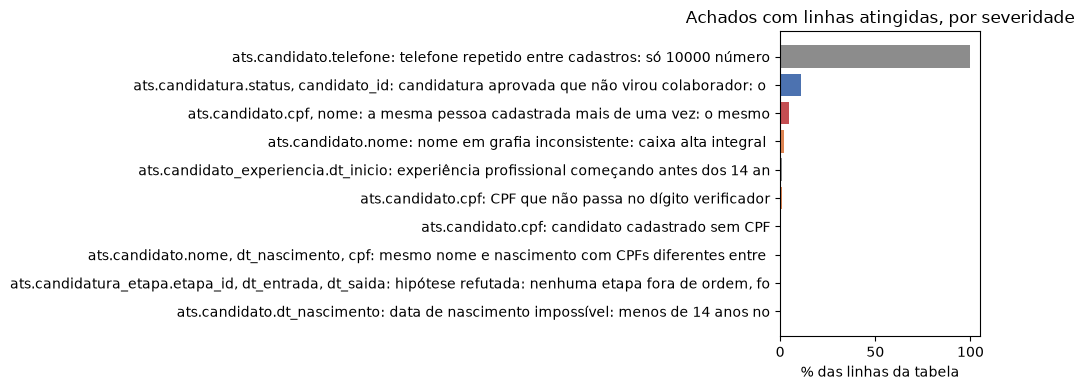

registro gravado em dados/auditoria/ats.json


In [24]:
com_linhas = quadro[quadro["linhas"] > 0].sort_values("pct")
if len(com_linhas):
    fig, eixo = plt.subplots(figsize=(10, max(3, 0.4 * len(com_linhas))))
    cores = {"alta": "#C44E52", "media": "#DD8452", "baixa": "#8C8C8C", "nenhuma": "#4C72B0"}
    eixo.barh(com_linhas["tabela"] + "." + com_linhas["coluna"] + ": " + com_linhas["achado"].str.slice(0, 50), com_linhas["pct"], color=[cores[s] for s in com_linhas["severidade"]])
    eixo.set_xlabel("% das linhas da tabela")
    eixo.set_title("Achados com linhas atingidas, por severidade")
    plt.tight_layout()
    plt.show()
caminho = registro.salvar(REFERENCIA.isoformat())
print(f"registro gravado em {caminho.relative_to(RAIZ)}")
con.close()

## Nota Técnica de fechamento

**O que foi examinado:** as 9 tabelas do domínio `ats`, 87 colunas e 1,21 milhão de linhas vivas, na carga identificada na seção 2: tipo, completude com coerência de status, unicidade por chave e duplicidade de pessoa, domínios, texto e documentos, cronologia do funil, integridade referencial e as regras do negócio.

**O veredicto: o fluxo é íntegro e o cadastro de pessoa é o problema, exatamente como o cliente declarou.** As três declarações se confirmam com número: 2.735 cadastros compartilham 1.349 CPFs (sempre com o nome em outra grafia), 457 CPFs não passam no dígito verificador e 94 datas de nascimento são impossíveis. A grafia inconsistente do nome (caixa alta, inicial abreviada) é o mecanismo da duplicidade. Em volta disso, o funil é confiável: nenhuma etapa fora de ordem, nenhuma data invertida, nenhum órfão, domínios limpos. Os achados que ficam para o catálogo são oito: um alto (duplicidade por CPF), quatro médios (nome e nascimento iguais com CPFs diferentes, CPF inválido, nascimento impossível, grafia do nome), três baixos (CPF ausente, telefone que não identifica, experiência antes dos 14 anos), mais dois registros de severidade nenhuma (no-show do primeiro dia, que é indicador e não defeito; cronologia íntegra).

**Próximos passos:** `pessoas`, onde as pessoas aprovadas viram colaboradores, e onde se confere se a duplicidade e o documento inválido atravessaram a admissão.